In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import nltk

nltk.download('punkt')
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer, HashingVectorizer
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud, STOPWORDS
from transformers import pipeline
from sklearn.svm import LinearSVC

[nltk_data] Downloading package punkt to /home/samsam/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
df = pd.read_csv('hasilPreprocessing.csv')
df

,Comment
0,jawab
1,tanya retno aja jawab tidak nyambung wkwkwkwkwk
2,jawab panjang lebar kurang nyambung ngdabrus d...
3,bukti mana wowo
4,tahu pnm bantu masyarakat membudidayakan piuta...
...,...
7919,sorry bang sekolah gua manfaat
7920,manfaat didik gratis lebih ngena
7921,mbg bayar pajak klw tidak mana dana mbg pikir ...
7922,mbg apa pajak


# Labeling

In [4]:
# Load sentiment classifier
classifier = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

# bersihkan kolom
df['Comment'] = df['Comment'].fillna("").astype(str)

# Jika ada list (hasil tokenizing), ubah ke string
df['Comment'] = df['Comment'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else x
)

# Fungsi prediksi sentimen (versi aman)
def prediksi_sentimen(teks):
    teks = str(teks).strip()

    # handle kosong / aneh
    if teks == "" or len(teks) < 2:
        return "neutral"

    try:
        hasil = classifier(teks)
        return hasil[0]['label']
    except Exception as e:
        return "error"

# Terapkan ke dataframe
df['sentimen'] = df['Comment'].apply(prediksi_sentimen)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
sentimen_counts = df.sentimen.value_counts()
sentimen_counts

sentimen
negative    4427
neutral     2244
positive    1253
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

## Bar chart

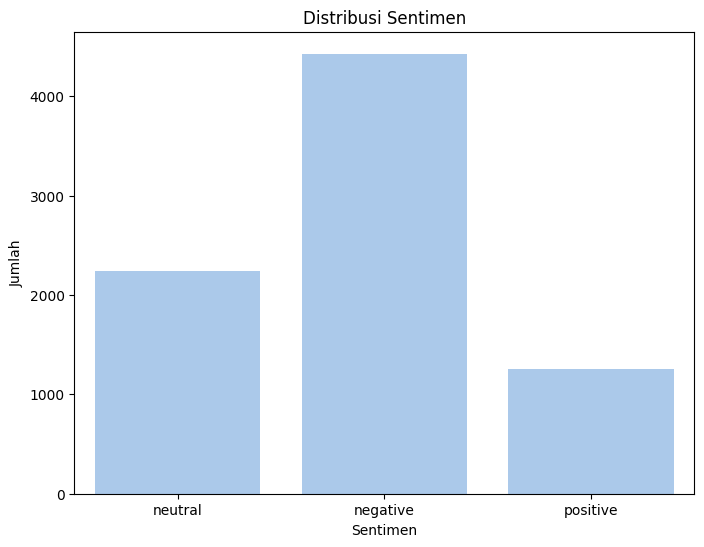

In [6]:
sns.set_palette("pastel")
plt.figure(figsize=(8, 6))
sns.countplot(x='sentimen', data=df)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

## Wordcloud

In [7]:
data_negatif = df[df['sentimen'] == 'negative']
data_positif = df[df['sentimen'] == 'positive']
data_netral = df[df['sentimen'] == 'neutral']

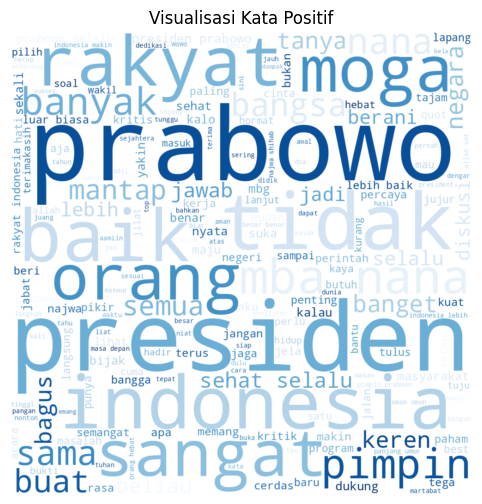

In [8]:
all_text_s1 = ' '.join(word for word in data_positif["Comment"])
wordcloud = WordCloud(colormap='Blues', width=1000, height=1000, mode="RGBA", background_color='white').generate(all_text_s1)
plt.figure(figsize=(9, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Visualisasi Kata Positif")
plt.margins(x=0, y=0)
plt.show()

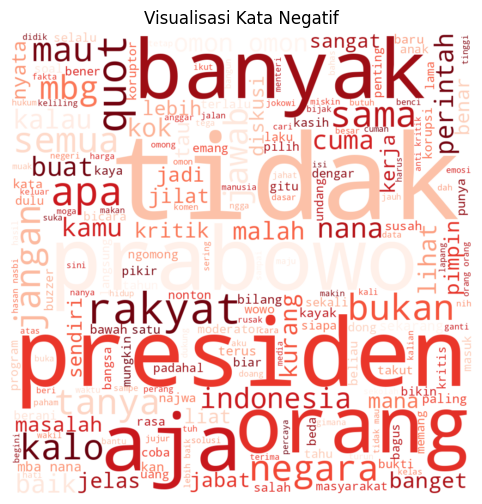

In [9]:
all_text_s0 = ' '.join(word for word in data_negatif["Comment"])
wordcloud = WordCloud(colormap='Reds', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s0)
plt.figure(figsize=(9, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Visualisasi Kata Negatif")
plt.margins(x=0, y=0)
plt.show()

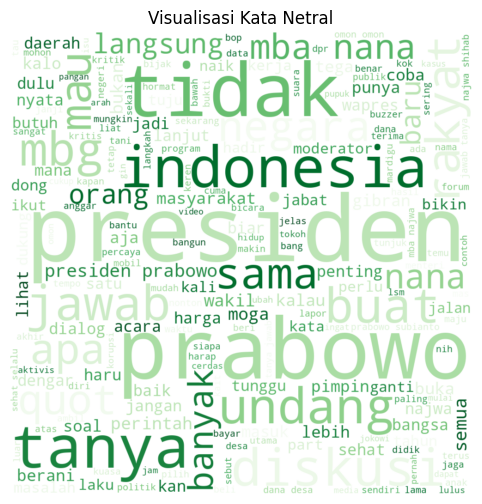

In [10]:
all_text_s2 = ' '.join(word for word in data_netral["Comment"])
wordcloud = WordCloud(colormap='Greens', width=1000, height=1000, mode='RGBA', background_color='white').generate(all_text_s2)
plt.figure(figsize=(9, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Visualisasi Kata Netral")
plt.margins(x=0, y=0)
plt.show()

# Training

### Support Vector Machine (SVM) -> Support Vector Classifier Linear

In [11]:
print(df['sentimen'].value_counts())

sentimen
negative    4427
neutral     2244
positive    1253
Name: count, dtype: int64


In [12]:
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['Comment']) 
y = df['sentimen']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_pred = model.predict(X_test)

In [14]:
model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

## Confusion Matrix

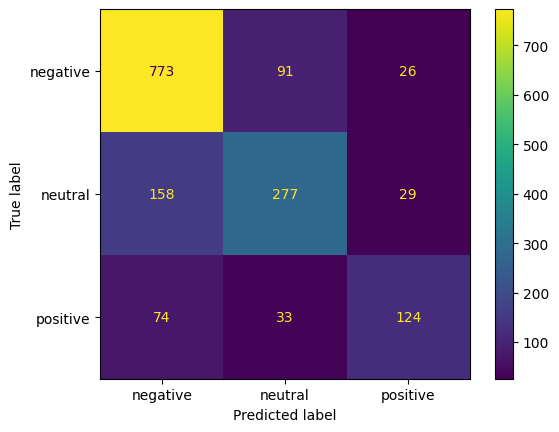

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## Classification report

In [18]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.77      0.87      0.82       890
     neutral       0.69      0.60      0.64       464
    positive       0.69      0.54      0.60       231

    accuracy                           0.74      1585
   macro avg       0.72      0.67      0.69      1585
weighted avg       0.74      0.74      0.73      1585



# Testing

In [19]:
def classify_text(text):
    text = text.lower()
    text_tfidf = vectorizer.transform([text])
    return model.predict(text_tfidf)[0]

In [20]:
while True:
    input_text = input("\nMasukkan teks (ketik 'exit' untuk keluar): ")
    
    if input_text.lower() == 'exit':
        break
    
    hasil = classify_text(input_text)
    print("Hasil Sentimen:", hasil)


Masukkan teks (ketik 'exit' untuk keluar):  prabowo


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  indonesia


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  buruk sekali


Hasil Sentimen: negative



Masukkan teks (ketik 'exit' untuk keluar):  wkwk


Hasil Sentimen: negative



Masukkan teks (ketik 'exit' untuk keluar):  berita


Hasil Sentimen: negative



Masukkan teks (ketik 'exit' untuk keluar):  mbg


Hasil Sentimen: negative



Masukkan teks (ketik 'exit' untuk keluar):  makan bergizi gratis


Hasil Sentimen: neutral



Masukkan teks (ketik 'exit' untuk keluar):  exit
